In [54]:
import ratinabox
from ratinabox.Agent import Agent
from ratinabox.Neurons import PlaceCells
from ratinabox.contribs.NeuralNetworkNeurons import NeuralNetworkNeurons #for the Actor and Critic
from ratinabox.contribs.TaskEnvironment import (SpatialGoalEnvironment, SpatialGoal, Reward)

#misc
import torch 
import numpy as np 
from gymnasium.spaces import Box
from tqdm import tqdm
import time
import random

from plotting_utils import *
from base_actor_critic import *
from training_utils import *

In [64]:
#TASK CONSTANTS
DT = 0.1 # Time step
T_TIMEOUT = 50 # Time out
GOAL_POS = np.array([0.5, 0.5]) # Goal position
WALL = None
# WALL = [[0.8, 0.0], [0.8, 0.8]]
GOAL_RADIUS = 0.1
REWARD = 1 # Reward
REWARD_DURATION = 1 # Reward duration

#LEARNING CONSTANTS
TAU = 5 # Discount time horizon
TAU_E = 5 # Eligibility trace time horizon
ETA = 0.01 # Learning rate 
N_EPISODES = 50 # Number of episodes
L2 = 0.000 # L2 regularization

In [65]:
env = SpatialGoalEnvironment(
        dt=DT,
        teleport_on_reset=True, # change this to False if you want the agent to start at the same position at the start of each episode
        episode_terminate_delay=REWARD_DURATION)
env.exploration_strength = 0 
if WALL is not None: 
    env.add_wall(WALL)
#Make the reward which is given when a spatial goal is satisfied. Attached this goal to the environment
reward = Reward(REWARD,decay="none",expire_clock=REWARD_DURATION,dt=DT,)
goals = [SpatialGoal(env,pos=GOAL_POS,goal_radius=GOAL_RADIUS, reward=reward)]
env.goal_cache.reset_goals = goals 
#Recruit the agent and add it to environment
ag = Agent(env,params={'dt':DT})
env.add_agents(ag)

(<Figure size 250x250 with 1 Axes>, <Axes: >)

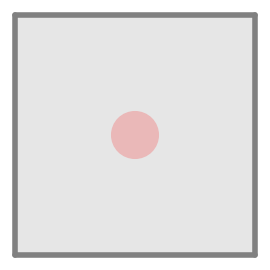

In [66]:
fig, ax = env.plot_environment()
display_reward_patch(fig,ax,reward_pos=GOAL_POS, reward_radius=0.1)

 fta_eta: 2, n_tilings: 1, n_tiles: 10


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ratinabox/utils.py:837: UserWarning: Cannot collect the default_params dictionaries, as Actor does not have the class attribute 'default_params' defined in its preamble. (Can be just an empty dictionary, i.e.: default_params = dict().)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ratinabox/utils.py:892: UserWarning: Cannot check the keys in the params dictionary, as <class 'base_actor_critic.Actor'> does not have a class attribute 'default_params' defined in its preamble. (Can be just an empty dictionary, i.e.: default_params = dict().)
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ratinabox/utils.py:837: UserWarning: Cannot collect the default_params dictionaries, as Critic does not have the class attribute 'default_params' defined in its preamble. (Can be just an empty dictionary, i.e.: default_params = 

Text(0.5, 1.0, 'Vy')

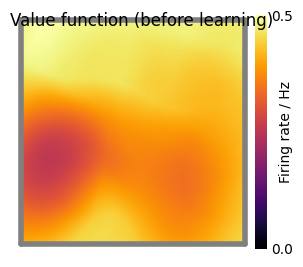

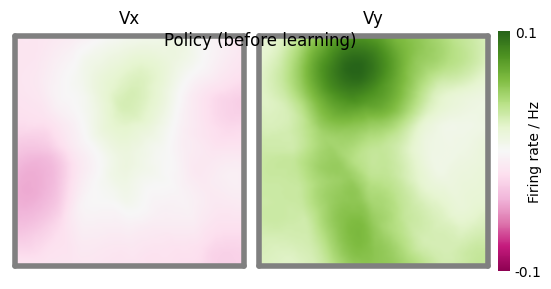

In [67]:
placecells = PlaceCells(ag, params={'n':50}) 

#Make the actor and the critic (first make their core NNs then pass these to the full Actor and Critic classes)

# actorNN  = VxVyGaussianFTA(n_in=placecells.n,post_fta=[2])
actorNN = VxVyGaussianMLP(n_in=placecells.n)
criticNN = FTANetwork(n_in=placecells.n,post_fta=[1],eta=2)
#
default_params_actor = {
        "tau": TAU, #The time horizon of the value function 
        "tau_z": TAU_E, #The time horizon of the eligibility trace
        "input_layers": [placecells],  # a list of input layers, each must be a ratinabox.Neurons class
        "NeuralNetworkModule": actorNN, #Any torch nn.Sequential or nn.Module with a .forward() method
        "optimizer": lambda params: torch.optim.SGD(params, lr=ETA,  maximize=True, weight_decay=L2), #The optimizer to use (in practise I've tried Adam but it aint great). Also, remember this must maximize not minimize. 
        "eligibility_traces": True, #Whether to use eligibility traces or not. If False, then the update is based on the current state only, rather than a decaying trace of past states.
        }
actor  = Actor(ag, params = default_params_actor); actor.colormap="PiYG"

default_params_critic = {
        "tau": TAU, #The time horizon of the value function 
        "tau_z": TAU_E, #The time horizon of the eligibility trace
        "input_layers": [placecells],  # a list of input layers, each must be a ratinabox.Neurons class
        "NeuralNetworkModule": criticNN, #Any torch nn.Sequential or nn.Module with a .forward() method
        "optimizer": lambda params: torch.optim.SGD(params, lr=ETA,  maximize=True, weight_decay=L2), #The optimizer to use (in practise I've tried Adam but it aint great). Also, remember this must maximize not minimize. 
        "eligibility_traces": True, #Whether to use eligibility traces or not. If False, then the update is based on the current state only, rather than a decaying trace of past states.
        }
critic = Critic(ag, params = default_params_critic)

#This visualises the value function and "policy" over the entire environment
fig, ax = critic.plot_rate_map(); fig.suptitle("Value function (before learning)")
fig, ax = actor.plot_rate_map(zero_center=True); fig.suptitle("Policy (before learning)"); ax[0].set_title("Vx"); ax[1].set_title("Vy")

In [68]:
def find_fta_module(net: torch.nn.Module):
    '''Find FTA layer in a network and print the type of each module as it searches'''
    for m in net.modules():
        print(type(m))
        if isinstance(m, FTA):
            return m
    raise ValueError("No FTA module found in the network.")

In [69]:
# Assuming critic, actor, ag, placecells, and env are already created
fta = find_fta_module(critic.NeuralNetworkModule)

hook_fn, fta_sparsity, fta_states, fta_times = create_fta_hook(fta, ag, env)
handle = fta.register_forward_hook(hook_fn)

# Run one episode
run_episode(env, ag, actor, critic, state_cells=[placecells], time_limit=T_TIMEOUT, seed=0)

# Remove the hook
handle.remove()

<class 'base_actor_critic.FTANetwork'>
<class 'torch.nn.modules.container.Sequential'>
<class 'torch.nn.modules.linear.Linear'>
<class 'torch.nn.modules.activation.ReLU'>
<class 'fta.FTA'>


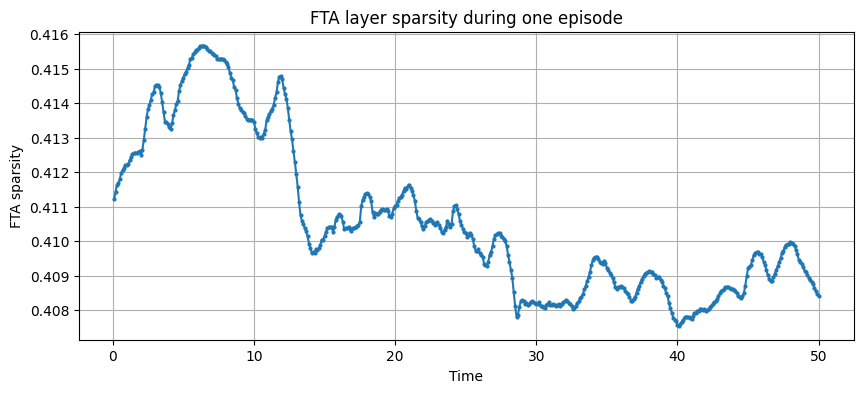

In [70]:
# -----------------------------------
# Plot sparsity over time
# -----------------------------------
plt.figure(figsize=(10,4))
plt.plot(fta_times, fta_sparsity, marker='o', markersize=2)
plt.xlabel("Time")
plt.ylabel("FTA sparsity")
plt.title("FTA layer sparsity during one episode")
plt.grid(True)
plt.show()

In [62]:
env.episodes

{'episode': [1, 2],
 'start': [0, 9.299999999999983],
 'end': [9.299999999999983],
 'duration': [9.299999999999983],
 'meta_info': ['completed']}

(<Figure size 250x250 with 1 Axes>, <Axes: >)

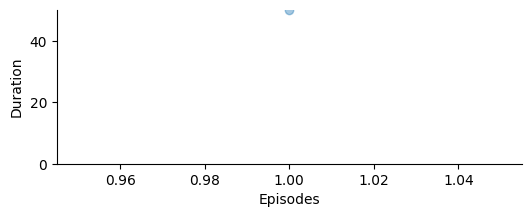

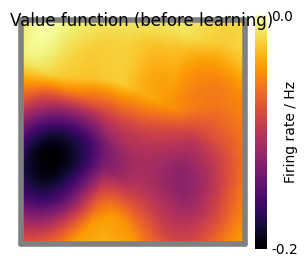

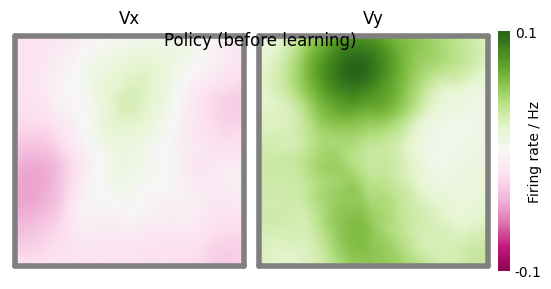

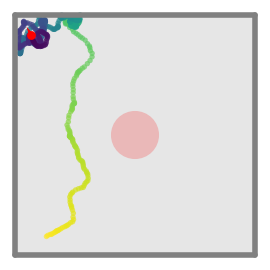

In [71]:
#This plots the reward history over training
fig, ax = plot_reward_history(env)
#This visualises the value function and "policy" over the entire environment
fig, ax = critic.plot_rate_map(); fig.suptitle("Value function (before learning)")
fig, ax = actor.plot_rate_map(zero_center=True); fig.suptitle("Policy (before learning)"); ax[0].set_title("Vx"); ax[1].set_title("Vy")
#Shows the trajectory of the agent over the last 100 episodes
fig, ax = ag.plot_trajectory(color="changing",t_start=env.episodes['start'][0],t_end=env.episodes['start'][0]); display_reward_patch(fig,ax, reward_pos=GOAL_POS, reward_radius=0.1)